In [6]:
import scanpy as sc
import pandas as pd
import anndata as ad
import numpy as np
import squidpy as sq
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_table("data/xenium/rep1/singlecells.txt")
df.dropna(axis=1, how='all', inplace=True) # Remove columns of all NaN
df.dropna(inplace=True) # Drop rows containing NaN

In [8]:
df_adata = df[['Object ID']+df.columns[pd.Series(df.columns).str.startswith('xenium:cell_transcript:')].tolist()]
df_adata.set_index("Object ID", inplace = True)
df_adata.columns = [t.replace('xenium:cell_transcript:','') for t in df_adata.columns.tolist()]

In [9]:
df_adata

,ABCC11,ACTA2,ACTG2,ADAM9,ADGRE5,ADH1B,ADIPOQ,AGR3,AHSP,AIF1,...,TUBB2B,TYROBP,UCP1,USP53,VOPP1,VWF,WARS,ZEB1,ZEB2,ZNF562
Object ID,,,,,,,,,,,,,,,,,,,,,
250fdaa9-2a48-445b-9003-ae013ac87c72,2.0,9.0,8.0,0.0,1.0,4.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2.0,6.0,0.0
ff97bfd2-f41a-4824-85da-2f612f199444,3.0,6.0,11.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,3.0,2.0,1.0,0.0
4699c743-c24f-4ab8-8f67-0e43d3f16ed9,1.0,6.0,10.0,5.0,2.0,1.0,0.0,0.0,0.0,5.0,...,0.0,0.0,0.0,0.0,2.0,24.0,4.0,1.0,8.0,0.0
8db540f5-1b43-4fdb-93fc-d04172991183,0.0,3.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,2.0,1.0,0.0,1.0,0.0
730370dd-9898-41e0-86a2-919a7db92951,0.0,3.0,8.0,1.0,0.0,2.0,2.0,0.0,0.0,3.0,...,0.0,1.0,0.0,0.0,1.0,2.0,0.0,0.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
cdc38215-9dfb-4ed8-b589-851b03b227dd,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0
828e7829-ba42-4b9a-8626-d09cbf4dabb3,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ac135249-0cbc-464e-9a77-be3c5b680f5d,1.0,0.0,0.0,3.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,4.0,1.0


In [10]:
adata = ad.AnnData(csr_matrix(df_adata.values))
adata.obs_names = df_adata.index
adata.var_names = df_adata.columns
adata.obs.index = adata.obs.index.astype(str)
adata.obsm["spatial"] = df[['Centroid X µm','Centroid Y µm']].to_numpy()

/tmp/ipykernel_161031/1624468260.py:1: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = ad.AnnData(csr_matrix(df_adata.values))


/opt/anaconda3/envs/sptx2/lib/python3.8/site-packages/scanpy/preprocessing/_normalization.py:197: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


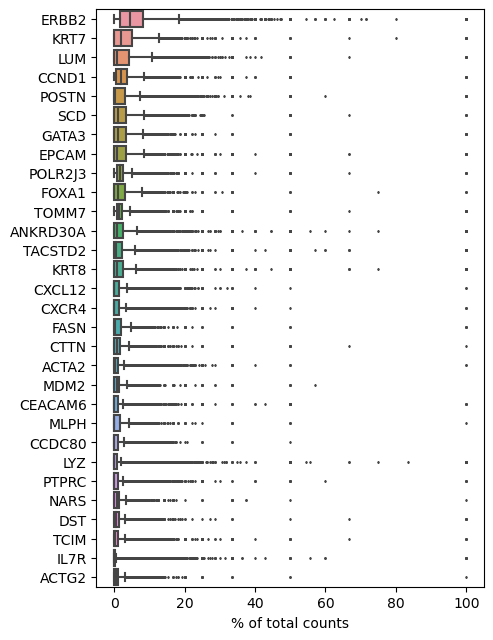

In [22]:
sc.pl.highest_expr_genes(adata, n_top=30)

In [21]:
adata.var_names_make_unique()
adata.var["mt"] = adata.var_names.str.startswith("mt-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"],percent_top=(50, 100, 200, 300), inplace=True)

/tmp/ipykernel_161031/2961596687.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(
/tmp/ipykernel_161031/2961596687.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(


<Axes: xlabel='n_genes_by_counts'>

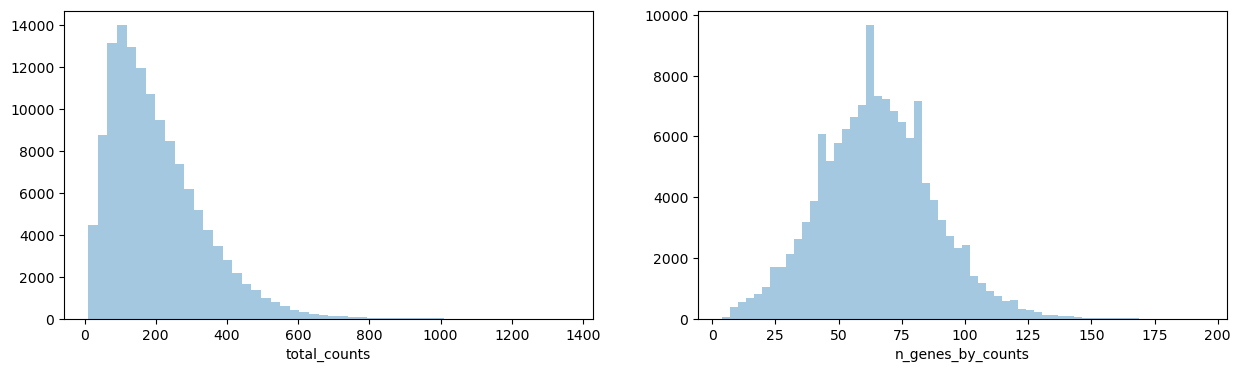

In [27]:
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
sns.distplot(
    adata.obs["total_counts"],
    kde=False,
    ax=axs[0],
)
sns.distplot(
    adata.obs["n_genes_by_counts"],
    kde=False,
    bins=60,
    ax=axs[1],
)

In [26]:
sc.pp.filter_cells(adata, min_counts=10)
sc.pp.filter_genes(adata, min_cells=5)

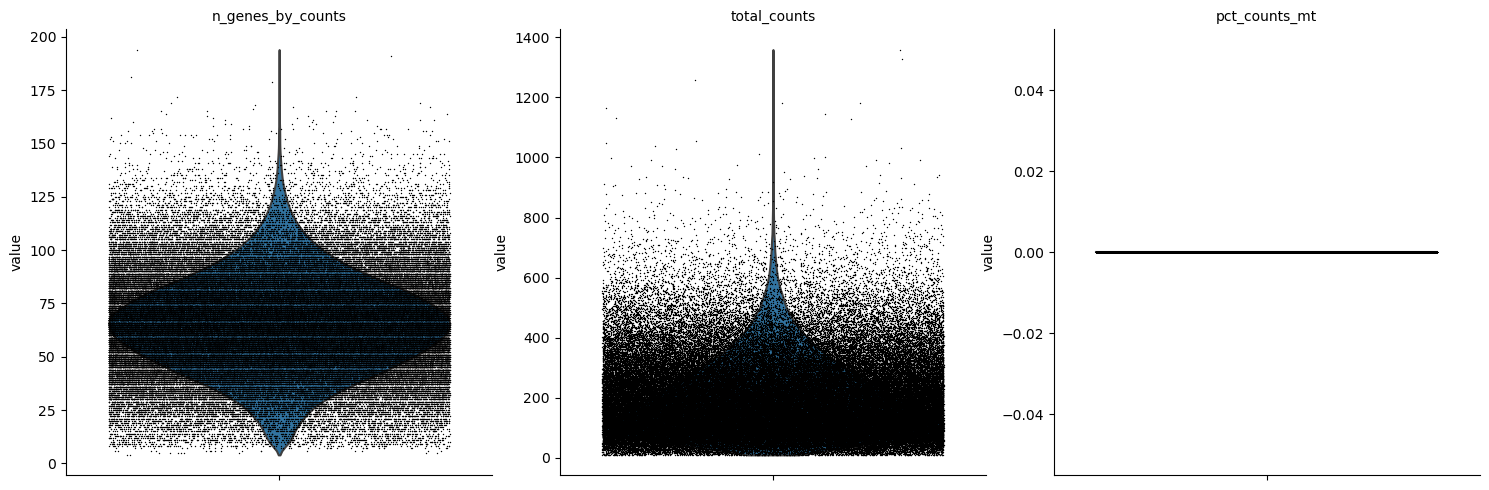

In [28]:
sc.pl.violin(
        adata,
        ["n_genes_by_counts", "total_counts",'pct_counts_mt'],
        jitter=0.4,
        multi_panel=True,
    )

In [29]:
# define outliers and do the filtering for the 3k dataset
adata.obs['outlier_total'] = adata.obs.total_counts > 800
adata.obs['outlier_ngenes'] = adata.obs.n_genes_by_counts > 150

print('%u cells with large total counts' % (sum(adata.obs['outlier_total'])))
print('%u cells with large number of genes' % (sum(adata.obs['outlier_ngenes'])))

adata = adata[~adata.obs['outlier_total'], :]
adata = adata[~adata.obs['outlier_ngenes'], :]

156 cells with large total counts
101 cells with large number of genes


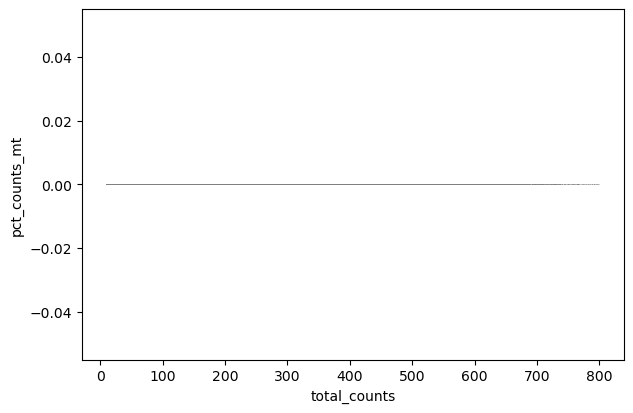

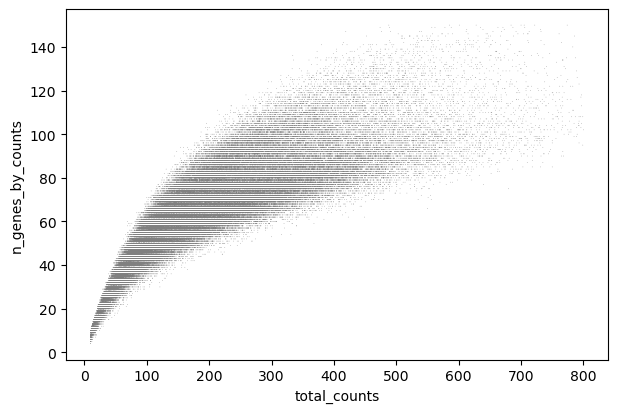

In [30]:
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts')

In [31]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.tl.leiden(adata, key_added="clusters")

/opt/anaconda3/envs/sptx2/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2023-03-06 20:46:52.891182: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


/opt/anaconda3/envs/sptx2/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


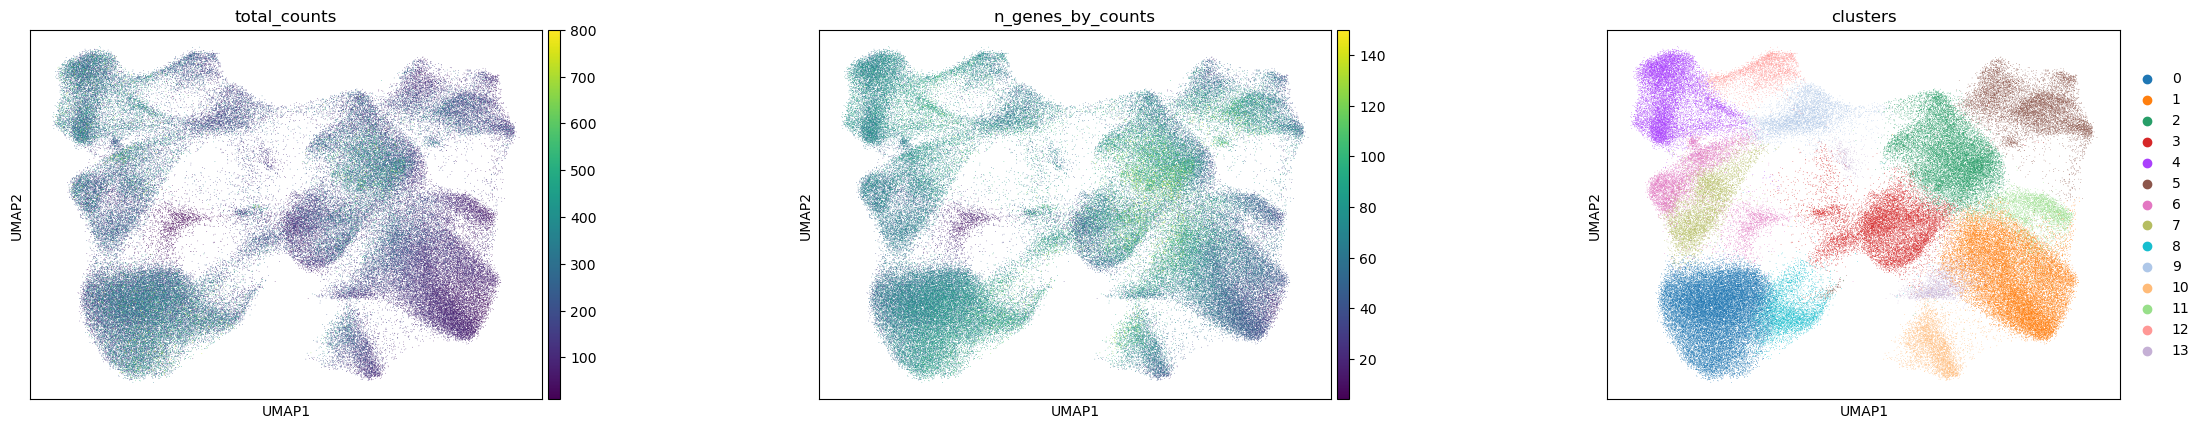

In [32]:
sc.pl.umap(
    adata,
    color=[
        "total_counts",
        "n_genes_by_counts",
        "clusters",
    ],
    wspace=0.4,
)

/opt/anaconda3/envs/sptx2/lib/python3.8/site-packages/squidpy/pl/_spatial_utils.py:955: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


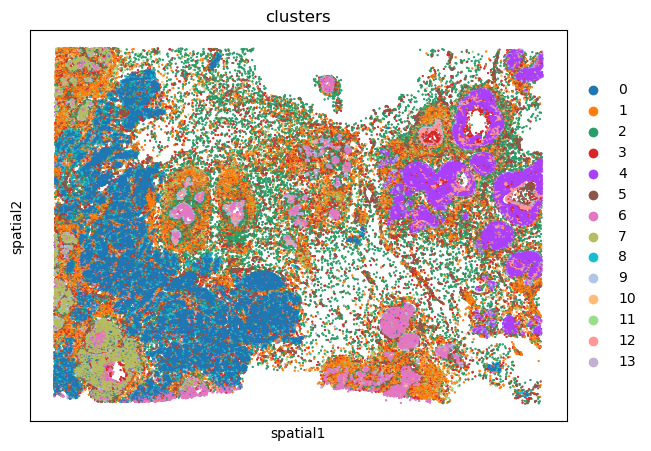

In [33]:
sq.pl.spatial_scatter(adata, library_id="spatial", shape=None,color=[
        "clusters",
    ],
    wspace=0.4,)

In [34]:
sq.gr.spatial_neighbors(adata, coord_type="generic", delaunay=True)

In [35]:
sq.gr.centrality_scores(adata, cluster_key="clusters")

In [36]:
adata_subsample = sc.pp.subsample(adata, fraction=0.5, copy=True)

In [ ]:
sq.gr.co_occurrence(
    adata_subsample,
    cluster_key="clusters",
)
sq.pl.co_occurrence(
    adata_subsample,
    cluster_key="clusters",
    clusters="12",
    figsize=(10, 10),
)
sq.pl.spatial_scatter(
    adata_subsample,
    color="clusters",
    shape=None,
    size=2,
)

In [ ]:
sq.gr.nhood_enrichment(adata, cluster_key="clusters")

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(13, 7))
sq.pl.nhood_enrichment(
    adata,
    cluster_key="clusters",
    figsize=(8, 8),
    title="Neighborhood enrichment adata",
    ax=ax[0],
)
sq.pl.spatial_scatter(adata_subsample, color="clusters", shape=None, size=2, ax=ax[1])

In [ ]:
sq.gr.spatial_neighbors(adata_subsample, coord_type="generic", delaunay=True)
sq.gr.spatial_autocorr(
    adata_subsample,
    mode="moran",
    n_perms=100,
    n_jobs=1,
)
adata_subsample.uns["moranI"].head(10)


In [ ]:
sq.pl.spatial_scatter(
    adata_subsample,
    library_id="spatial",
    color=[
        "KRT7",
        "FOXA1",
    ],
    shape=None,
    size=2,
    img=False,
)

In [ ]:
sc.tl.dendrogram(adata, groupby='clusters')
sc.tl.rank_genes_groups(adata, "clusters", method="t-test")
sc.pl.rank_genes_groups_heatmap(adata, groups="012", n_genes=30, groupby="clusters")

In [ ]:
sc.tl.rank_genes_groups(adata, 'clusters', method='wilcoxon')
sc.pl.rank_genes_groups(adata, n_genes=30, sharey=False)

In [ ]:
num = 2
marker_genes = list(set(np.array(pd.DataFrame(adata.uns['rank_genes_groups']['names']).head(num)).reshape(-1)))
len(marker_genes)

In [ ]:
sc.pl.dotplot(adata, marker_genes, groupby='clusters');

In [ ]:
sc.pl.stacked_violin(adata, marker_genes, groupby='clusters', rotation=90);

In [ ]:
sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=50)
sc.pl.highly_variable_genes(adata)

In [ ]:
# adata.obs['clusters'].to_csv('predicted_with_membrane_singlecell_clusters.csv')